<a href="https://colab.research.google.com/github/JozefSL/EIA/blob/main/extractwtidataRecentSTEOhistory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import os # Import the os module for file operations

url = 'https://www.eia.gov/outlooks/steo/outlook.php'

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    soup = BeautifulSoup(response.text, 'html.parser')

    print("Successfully fetched the webpage. Now looking for download links...")

    all_links = []
    for a_tag in soup.find_all('a', href=True):
        href = a_tag['href']
        # Resolve relative URLs to absolute URLs
        if not href.startswith('http'):
            href = requests.compat.urljoin(url, href)
        all_links.append(href)

    month_abbr_to_num = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }
    month_abbr_list = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Filter for historical forecast data files (ending in .xlsx or .xls and in archives)
    # and restrict to files published after 2019
    filtered_historical_data_links = []
    for link in all_links:
        if 'archives' in link and (link.endswith('.xlsx') or link.endswith('.xls')):
            file_name = link.split('/')[-1]
            match = re.search(r'([a-z]{3})(\d{2})_base\.(xlsx|xls)', file_name)
            if match:
                year_suffix = int(match.group(2))
                full_year = 2000 + year_suffix if year_suffix < 50 else 1900 + year_suffix # Heuristic for 2-digit years
                if full_year >= 2019: # Only include files from 2019 onwards
                    filtered_historical_data_links.append(link)

    # Sort in reverse to process newest first, assuming this is desired for initial inspection
    historical_data_links = sorted(filtered_historical_data_links, reverse=True)

    if historical_data_links:
        print(f"Found {len(historical_data_links)} potential historical forecast data links in archives.")
        print("Downloading and processing files...")

        all_extracted_rows = []

        for link_idx, link in enumerate(historical_data_links):
            file_name = link.split('/')[-1]
            print(f"({link_idx + 1}/{len(historical_data_links)}) Attempting to download {file_name} from: {link}")

            try:
                file_response = requests.get(link, stream=True)
                file_response.raise_for_status()

                with open(file_name, 'wb') as f:
                    for chunk in file_response.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"Successfully downloaded {file_name}")

                # Extract publication month and year from file_name
                pub_match = re.search(r'([a-z]{3})(\d{2})_base\.(xlsx|xls)', file_name)
                pub_year, pub_month_num = None, None
                if pub_match:
                    pub_month_abbr = pub_match.group(1).lower()
                    pub_year_suffix = int(pub_match.group(2))
                    pub_year = 2000 + pub_year_suffix if pub_year_suffix < 50 else 1900 + pub_year_suffix
                    pub_month_num = month_abbr_to_num.get(pub_month_abbr)

                # Read the '2tab' sheet into a pandas DataFrame without headers
                if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
                    try:
                        df_raw = pd.read_excel(file_name, sheet_name='2tab', header=None)

                        # Extract relevant rows (0-indexed)
                        year_row = df_raw.iloc[2] # Row 3 in Excel
                        month_row = df_raw.iloc[3] # Row 4 in Excel
                        data_row = df_raw.iloc[5] # Row 6 in Excel

                        current_year = None
                        # Iterate through columns starting from the third column (index 2)
                        for col_idx in range(2, len(data_row)):
                            # Update current_year from row 3, handling merged cells (NaNs)
                            if pd.notna(year_row[col_idx]):
                                try:
                                    current_year = int(year_row[col_idx])
                                except ValueError:
                                    current_year = None # Reset if not a valid year number

                            month = month_row[col_idx]
                            value = data_row[col_idx]

                            # Only append if we have valid year, month, and value
                            if current_year is not None and pd.notna(month) and pd.notna(value) and month in month_abbr_list:
                                data_month_num = month_abbr_to_num.get(month.lower())

                                # Filter: only include data if it's the publication month or later for that file's forecast
                                if pub_year is not None and pub_month_num is not None:
                                    if (current_year > pub_year) or \
                                       (current_year == pub_year and data_month_num >= pub_month_num):

                                        all_extracted_rows.append({
                                            'Year': current_year,
                                            'Month': month,
                                            'Value': value,
                                            'Source_File': file_name
                                        })
                        print(f"Successfully extracted data from '2tab' row 6 of {file_name} (filtered for future/current months).")

                    except ValueError as ve:
                        print(f"Sheet '2tab' not found or other parsing error in {file_name}: {ve}")
                    except Exception as e:
                        print(f"Error reading Excel file {file_name} (sheet '2tab'): {e}")

                # Clean up the downloaded file after processing
                os.remove(file_name)
                print(f"Removed temporary file: {file_name}")

            except requests.exceptions.RequestException as e:
                print(f"Error downloading {file_name} from {link}: {e}")
            except Exception as e:
                print(f"An unexpected error occurred while processing {file_name}: {e}")

        if all_extracted_rows:
            print("\nConcatenating all extracted data into a final DataFrame...")
            final_df = pd.DataFrame(all_extracted_rows)

            # Create a 'Data_Date' column for easier calculation
            final_df['Month_Num'] = final_df['Month'].str.lower().map(month_abbr_to_num)
            final_df['Data_Date'] = pd.to_datetime(final_df['Year'].astype(str) + '-' + final_df['Month_Num'].astype(str) + '-01')

            def calculate_forecast_horizon(row):
                file_name = row['Source_File']
                pub_match = re.search(r'([a-z]{3})(\d{2})_base\.(xlsx|xls)', file_name)
                if pub_match:
                    pub_month_abbr = pub_match.group(1).lower()
                    pub_year_suffix = int(pub_match.group(2))
                    pub_year = 2000 + pub_year_suffix if pub_year_suffix < 50 else 1900 + pub_year_suffix
                    pub_month_num_for_map = month_abbr_to_num.get(pub_month_abbr)

                    if pub_year is not None and pub_month_num_for_map is not None:
                        forecast_start_date = pd.to_datetime(f"{pub_year}-{pub_month_num_for_map:02d}-01")
                        # Calculate difference in months
                        return ((row['Data_Date'].year - forecast_start_date.year) * 12 + (row['Data_Date'].month - forecast_start_date.month))
                return None

            final_df['Forecast_Horizon'] = final_df.apply(calculate_forecast_horizon, axis=1)

            # Drop temporary columns
            final_df = final_df.drop(columns=['Month_Num', 'Data_Date'])

            print("Concatenation complete. Head of the final DataFrame with Forecast_Horizon:")
            print(final_df.head())
            print(f"Total rows in the combined DataFrame: {len(final_df)}")
        else:
            print("No data from '2tab' sheets could be read and concatenated.")

    else:
        print("No direct historical forecast data files (.xls, .xlsx) found in archives (after filtering).")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL or general request error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully fetched the webpage. Now looking for download links...
Found 93 potential historical forecast data links in archives.
(1/93) Attempting to download sep26_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep26_base.xlsx
Successfully downloaded sep26_base.xlsx
Successfully extracted data from '2tab' row 6 of sep26_base.xlsx (filtered for future/current months).
Removed temporary file: sep26_base.xlsx
(2/93) Attempting to download sep25_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep25_base.xlsx
Successfully downloaded sep25_base.xlsx
Successfully extracted data from '2tab' row 6 of sep25_base.xlsx (filtered for future/current months).
Removed temporary file: sep25_base.xlsx
(3/93) Attempting to download sep24_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep24_base.xlsx
Successfully downloaded sep24_base.xlsx
Successfully extracted data from '2tab' row 6 of sep24_base.xlsx (filtered for future/current months).
Removed temporary file: sep

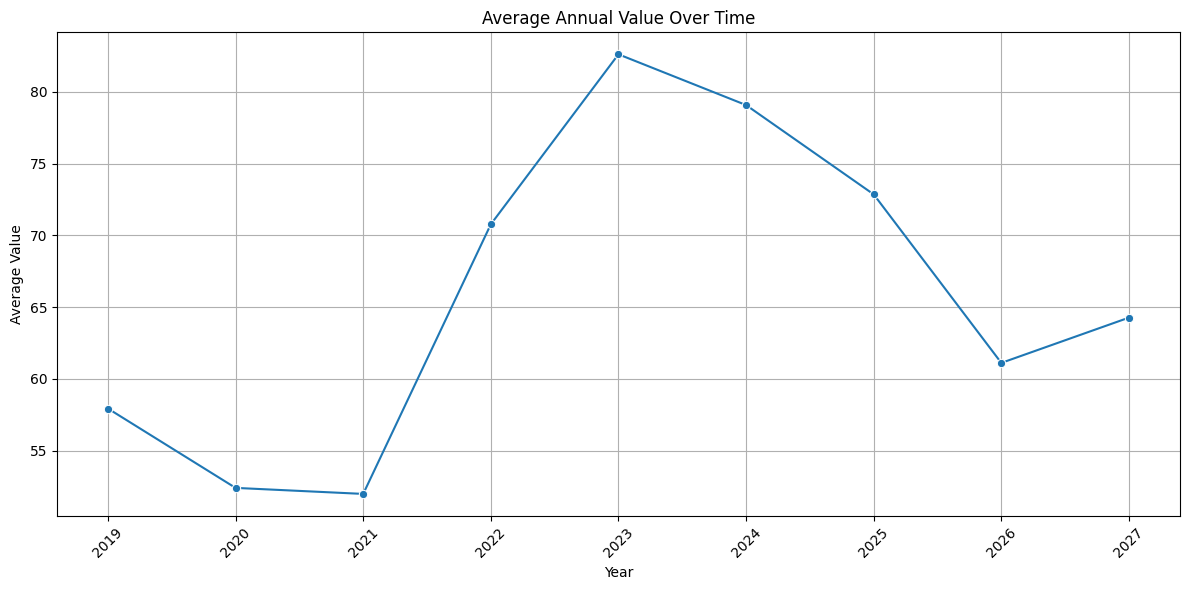

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average annual 'Value'
annual_avg_value = final_df.groupby('Year')['Value'].mean().reset_index()

# Plotting the average annual 'Value'
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Value', data=annual_avg_value, marker='o')
plt.title('Average Annual Value Over Time')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
final_df.head()

,Year,Month,Value,Source_File,Forecast_Horizon
0,2026,Sep,88.0,sep26_base.xlsx,0
1,2026,Oct,87.0,sep26_base.xlsx,1
2,2026,Nov,86.5,sep26_base.xlsx,2
3,2026,Dec,84.5,sep26_base.xlsx,3
4,2027,Jan,83.0,sep26_base.xlsx,4


In [4]:
import plotly.express as px
import pandas as pd

# Filter the DataFrame for 'aug25_base.xlsx'
df_aug25 = final_df[final_df['Source_File'] == 'aug25_base.xlsx'].copy()

# Ensure 'Year' is integer and 'Month' is string for plotting
df_aug25['Year'] = df_aug25['Year'].astype(int)

# Create a date-like column for better time series plotting
# Assuming 'Month' is a month name, we can map it to a number or concatenate with year
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_aug25['Month_Num'] = df_aug25['Month'].map(month_to_num)

# Create a 'Date' column for plotting
df_aug25['Date'] = pd.to_datetime(df_aug25['Year'].astype(str) + '-' + df_aug25['Month_Num'].astype(str) + '-01')

# Sort by Date to ensure correct plotting order
df_aug25 = df_aug25.sort_values(by='Date')

# Plotting the 'Value' for 'aug25_base.xlsx' over time using Plotly Express for interactivity
fig = px.line(df_aug25, x='Date', y='Value', title='Value Over Time for Source File: aug25_base.xlsx',
              hover_data={'Date': '|%Y-%m-%d', 'Value': True})

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Value',
    xaxis_tickformat='%Y-%m'
)

fig.show()


In [29]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

# Map month abbreviations to numbers if not already done, using the dictionary from the first cell
month_abbr_to_num = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Create a copy to avoid SettingWithCopyWarning
df_plot = final_df.copy()

# Convert 'Month' to numeric representation
df_plot['Month_Num'] = df_plot['Month'].str.lower().map(month_abbr_to_num)

# Create a 'Date' column for proper time-series plotting
df_plot['Date'] = pd.to_datetime(df_plot['Year'].astype(str) + '-' +
                                df_plot['Month_Num'].astype(str) + '-01')

# Sort by Date to ensure correct plotting order
df_plot = df_plot.sort_values(by='Date')

# Plotting the 'Value' for each 'Source_File' over time using Plotly Express
fig = px.line(df_plot,
              x='Date',
              y='Value',
              color='Source_File', # This creates a separate line for each unique Source_File
              title='Value Over Time by Source File',
              labels={'Date': 'Forecast Date', 'Value': 'Value', 'Source_File': 'Source File'},
              hover_data={'Date': '|%Y-%m-%d', 'Value': True, 'Source_File': True})

# Filter for Forecast_Horizon == 0
df_forecast_horizon_0 = df_plot[df_plot['Forecast_Horizon'] == 0].sort_values(by='Date')

# Add a new trace for Forecast_Horizon == 0
fig.add_trace(go.Scatter(
    x=df_forecast_horizon_0['Date'],
    y=df_forecast_horizon_0['Value'],
    mode='lines',
    name='Forecast Horizon 0',
    line=dict(color='gray', width=1) # Make this line distinct
))

fig.update_layout(
    xaxis_title='Forecast Date',
    yaxis_title='Value',
    xaxis_tickformat='%Y-%m'
)

fig.show()